In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
file_path = "Copy of all_lit_updated.xlsx"  
df = pd.read_excel(file_path)

df.head()

,unique_id,chem_form,press_GPa,Tc_K,space_group,DOS_EF_per_fu,DOS_EF_per_atom,DOS_H_frac,ave_valency,valency_per_H,r_ion_Angstrom,source,A,X,B,Y,N
0,1,RbH12,50.0,108.0,C2/m,NaN,NaN,0.15568,1.0,0.0833,1.66,Hutcheon_2020,Rb,1.0,NaN,NaN,12.0
1,2,RbH12,100.0,129.0,C2/m,NaN,NaN,0.18652,1.0,0.0833,1.66,Hutcheon_2020,Rb,1.0,NaN,NaN,12.0
2,3,RbH12,150.0,133.0,C2/m,NaN,NaN,0.20542,1.0,0.0833,1.66,Hutcheon_2020,Rb,1.0,NaN,NaN,12.0
3,4,RbH12,100.0,82.0,Cmcm,NaN,NaN,0.17611,1.0,0.0833,1.66,Hutcheon_2020,Rb,1.0,NaN,NaN,12.0
4,5,RbH12,50.0,115.0,Immm,NaN,NaN,NaN,1.0,0.0833,1.66,Hutcheon_2020,Rb,1.0,NaN,NaN,12.0


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (761, 17)

Columns:
['unique_id', 'chem_form', 'press_GPa', 'Tc_K', 'space_group', 'DOS_EF_per_fu', 'DOS_EF_per_atom', 'DOS_H_frac', 'ave_valency', 'valency_per_H', 'r_ion_Angstrom', 'source', 'A', 'X', 'B', 'Y', 'N']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   unique_id        761 non-null    int64  
 1   chem_form        761 non-null    object 
 2   press_GPa        737 non-null    float64
 3   Tc_K             759 non-null    float64
 4   space_group      462 non-null    object 
 5   DOS_EF_per_fu    50 non-null     float64
 6   DOS_EF_per_atom  140 non-null    float64
 7   DOS_H_frac       372 non-null    object 
 8   ave_valency      758 non-null    float64
 9   valency_per_H    761 non-null    float64
 10  r_ion_Angstrom   758 non-null    float64
 11  source           761 non-null    object 
 12  A                758 non-null    object 
 13  X                758 non-null    float64
 14  B                213 non-null    object 
 15  Y                213 non-null    float64
 16  N                758 non-null    float64
dtypes: float64(10), 

In [5]:
df.describe(include='object')

,chem_form,space_group,DOS_H_frac,source,A,B
count,761,462,372,761,758,213
unique,435,70,308,10,77,27
top,SiH4,C2/m,-,Belli_2021,Li,Y
freq,11,38,42,171,69,28


In [6]:
df["DOS_H_frac"] = df["DOS_H_frac"].replace("-", np.nan)

C:\Users\kotla\AppData\Local\Temp\ipykernel_51588\422540578.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["DOS_H_frac"] = df["DOS_H_frac"].replace("-", np.nan)


In [7]:
df.describe()

,unique_id,press_GPa,Tc_K,DOS_EF_per_fu,DOS_EF_per_atom,DOS_H_frac,ave_valency,valency_per_H,r_ion_Angstrom,X,Y,N
count,761.000000,737.000000,759.000000,50.000000,140.000000,330.000000,758.000000,761.000000,758.000000,758.000000,213.000000,758.000000
mean,381.000000,200.632293,90.280511,1.877712,0.192800,0.358154,3.220307,1.321130,0.999956,1.212117,1.620728,8.390501
std,219.826068,120.302073,84.875029,1.483800,0.169838,0.265029,1.733419,1.748572,0.236799,0.883514,0.930403,9.708459
min,1.000000,0.000000,0.000000,0.215909,0.008300,0.000530,0.000000,0.000000,0.360000,0.900000,0.040000,1.000000
25%,191.000000,100.000000,19.000000,0.925737,0.094725,0.153633,2.000000,0.300000,0.860000,1.000000,1.000000,3.000000
50%,381.000000,200.000000,67.000000,1.541667,0.141450,0.300190,3.000000,0.583300,0.980000,1.000000,1.000000,6.000000
75%,571.000000,295.000000,141.000000,2.046286,0.232700,0.531190,4.000000,1.500000,1.140000,1.000000,2.000000,11.000000
max,761.000000,610.000000,381.000000,6.653846,1.218500,1.000000,9.000000,14.000000,1.810000,10.000000,5.000000,86.000000


In [8]:
df = df.drop(columns=["unique_id"])

In [9]:
df = df[df["Tc_K"].notnull()]

In [10]:
df["ave_valency_missing"] = df["ave_valency"].isnull().astype(int)

In [11]:
df["ave_valency"] = df["ave_valency"].fillna(0)

In [12]:
df["r_ion_Angstrom_missing"] = df["r_ion_Angstrom"].isnull().astype(int)

In [13]:
df["r_ion_Angstrom"] = df["r_ion_Angstrom"].fillna(0)

In [14]:
df = df[df["press_GPa"].notnull()]

In [15]:
df = df.drop(columns=["DOS_EF_per_fu"])

In [16]:
df = df.drop(columns=["DOS_EF_per_atom"])

In [17]:
df = df.drop(columns=["DOS_H_frac"])

In [18]:
df = df.drop(columns=["space_group"])

In [19]:
df = df.drop(columns=["source"])

In [20]:
df.head()

,chem_form,press_GPa,Tc_K,ave_valency,valency_per_H,r_ion_Angstrom,A,X,B,Y,N,ave_valency_missing,r_ion_Angstrom_missing
0,RbH12,50.0,108.0,1.0,0.0833,1.66,Rb,1.0,NaN,NaN,12.0,0,0
1,RbH12,100.0,129.0,1.0,0.0833,1.66,Rb,1.0,NaN,NaN,12.0,0,0
2,RbH12,150.0,133.0,1.0,0.0833,1.66,Rb,1.0,NaN,NaN,12.0,0,0
3,RbH12,100.0,82.0,1.0,0.0833,1.66,Rb,1.0,NaN,NaN,12.0,0,0
4,RbH12,50.0,115.0,1.0,0.0833,1.66,Rb,1.0,NaN,NaN,12.0,0,0


In [21]:
df["B"] = df["B"].fillna("None")

In [22]:
df["Y"] = df["Y"].fillna("None")

In [23]:
df = df.dropna(subset=["A", "X", "N"])

In [24]:
df.isnull().sum()


chem_form                 0
press_GPa                 0
Tc_K                      0
ave_valency               0
valency_per_H             0
r_ion_Angstrom            0
A                         0
X                         0
B                         0
Y                         0
N                         0
ave_valency_missing       0
r_ion_Angstrom_missing    0
dtype: int64

In [25]:
df = df.drop(columns=["ave_valency_missing"])

In [26]:
df = df.drop(columns=["r_ion_Angstrom_missing"])

In [27]:
df.head()

,chem_form,press_GPa,Tc_K,ave_valency,valency_per_H,r_ion_Angstrom,A,X,B,Y,N
0,RbH12,50.0,108.0,1.0,0.0833,1.66,Rb,1.0,None,None,12.0
1,RbH12,100.0,129.0,1.0,0.0833,1.66,Rb,1.0,None,None,12.0
2,RbH12,150.0,133.0,1.0,0.0833,1.66,Rb,1.0,None,None,12.0
3,RbH12,100.0,82.0,1.0,0.0833,1.66,Rb,1.0,None,None,12.0
4,RbH12,50.0,115.0,1.0,0.0833,1.66,Rb,1.0,None,None,12.0


In [28]:
df = df.drop(columns=["A", "B", "Y", "N"])

In [29]:
df.head()

,chem_form,press_GPa,Tc_K,ave_valency,valency_per_H,r_ion_Angstrom,X
0,RbH12,50.0,108.0,1.0,0.0833,1.66,1.0
1,RbH12,100.0,129.0,1.0,0.0833,1.66,1.0
2,RbH12,150.0,133.0,1.0,0.0833,1.66,1.0
3,RbH12,100.0,82.0,1.0,0.0833,1.66,1.0
4,RbH12,50.0,115.0,1.0,0.0833,1.66,1.0


In [30]:
df = df.drop(columns=["X"])

In [31]:
X = df.drop(columns=["Tc_K", "chem_form"])
y = df["Tc_K"]



In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (585, 4)
X_test: (147, 4)
y_train: (585,)
y_test: (147,)


In [34]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 732 entries, 0 to 760
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   press_GPa       732 non-null    float64
 1   ave_valency     732 non-null    float64
 2   valency_per_H   732 non-null    float64
 3   r_ion_Angstrom  732 non-null    float64
dtypes: float64(4)
memory usage: 28.6 KB


In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


MSE: 1961.1334922393185
RMSE: 44.28468688202863
R2: 0.7231084071437919


In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score


rf_model = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 8],
    "min_samples_split": [ 2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=kf,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_pred_rf = y_pred

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)
print("MSE:", mse)
print("Test RMSE:", rmse)
print("Test R2:", r2)


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation Score: 0.617518457885552
MSE: 2046.4615817546717
Test RMSE: 45.23783352189483
Test R2: 0.7110609709469293


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor


model = XGBRegressor(
   
    random_state=42,
    objective="reg:squarederror"
)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 2608.521084273461
RMSE: 51.07368289318346
R2: 0.6317040319378006


In [36]:
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor



xgb_model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)


param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}


kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=kf,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)


best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_xgb = y_pred

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)
print("MSE:", mse)
print("Test RMSE:", rmse)
print("Test R2:", r2)
    

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best Cross-Validation Score: 0.6185379219723147
MSE: 1873.1173852349636
Test RMSE: 43.27952616694138
Test R2: 0.7355353633718507


In [57]:
results = pd.DataFrame({
    "Actual_Tc": y_test,
    "Predicted_Tc": y_pred
})

print(results.head(10))

     Actual_Tc  Predicted_Tc
633     35.000     40.166214
33     168.000    168.698837
321    170.000    147.040314
484      0.011     12.111754
663      3.000      5.474964
586     27.000     53.554272
39     326.000    247.030685
383     81.950     17.834530
755     25.000     83.840927
544     84.000    101.872307


In [48]:
import pandas as pd

new_data = pd.DataFrame({
    "press_GPa": [100, 150, 200],
    "ave_valency": [1.0, 2.0, 1.5],
    "valency_per_H": [0.08, 0.12, 0.10],
    "r_ion_Angstrom": [1.5, 1.8, 1.6]
})

In [49]:

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures

nn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("nn", MLPRegressor( 
        max_iter=1000,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.1,
    random_state=42,# patience
    solver='adam',
    ))
])
 
# Try different architectures and learning rates
param_grid_nn = {
    "nn__hidden_layer_sizes": [(8,), (16,), (32,)],  # small single layers
    "nn__learning_rate_init": [1e-3, 5e-3],           # fewer options
    "nn__alpha": [1e-3, 1e-2, 1e-1],                  # stronger regularization
    "nn__activation": ["relu", "tanh"],
    "nn__batch_size": [16, 32],
}
 
grid_nn = GridSearchCV(
    estimator=nn_pipeline,
    param_grid=param_grid_nn,
    cv=kf,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)
 
grid_nn.fit(X_train, y_train)
 
best_nn = grid_nn.best_estimator_
y_pred_nn = best_nn.predict(X_test)
 
mse_nn = mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print(f"Best Params : {grid_nn.best_params_}")
print(f"Best CV R²  : {grid_nn.best_score_:.4f}")
print(f"Test MSE    : {mse_nn:.4f}")
print(f"Test RMSE   : {rmse_nn:.4f}")
print(f"Test R²     : {r2_nn:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits


KeyboardInterrupt: 

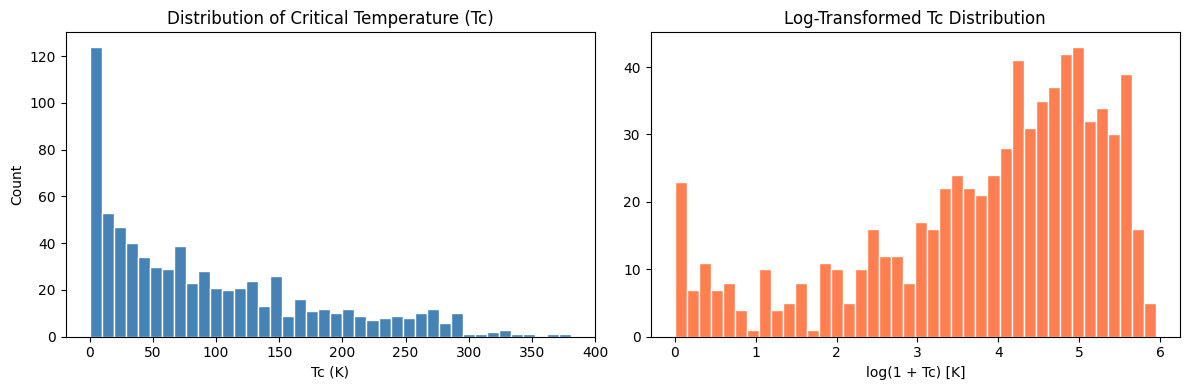

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw distribution
axes[0].hist(df['Tc_K'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Tc (K)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Critical Temperature (Tc)')

# Log-transformed (useful since data is right-skewed)
axes[1].hist(np.log1p(df['Tc_K']), bins=40, color='coral', edgecolor='white')
axes[1].set_xlabel('log(1 + Tc) [K]')
axes[1].set_title('Log-Transformed Tc Distribution')

plt.tight_layout()
plt.show()

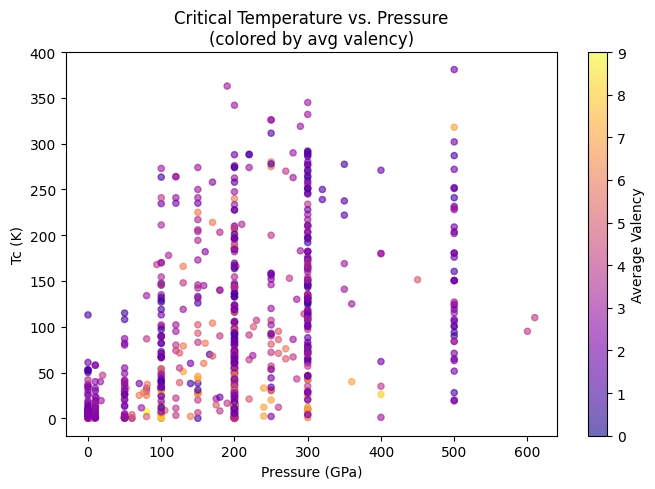

In [64]:
plt.figure(figsize=(7, 5))
sc = plt.scatter(df['press_GPa'], df['Tc_K'], 
                 c=df['ave_valency'], cmap='plasma', alpha=0.6, s=20)
plt.colorbar(sc, label='Average Valency')
plt.xlabel('Pressure (GPa)')
plt.ylabel('Tc (K)')
plt.title('Critical Temperature vs. Pressure\n(colored by avg valency)')
plt.tight_layout()
plt.show()

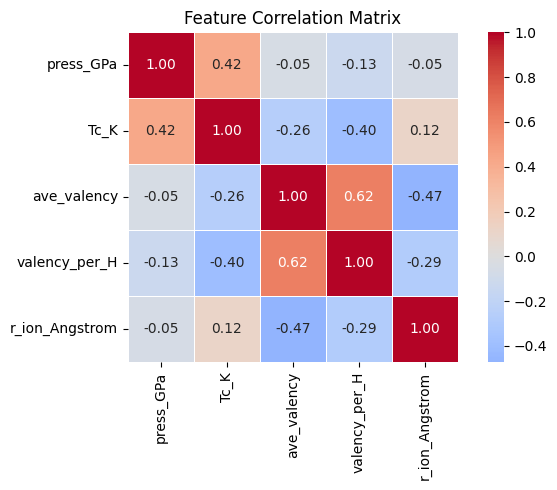

In [63]:
numeric_cols = ['press_GPa', 'Tc_K', 'ave_valency', 'valency_per_H', 'r_ion_Angstrom']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

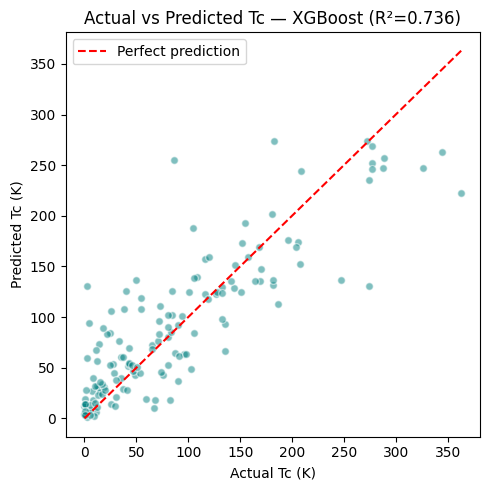

In [62]:
# After fitting best_xgb model and getting y_pred
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal', edgecolors='white', s=30)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Perfect prediction')
plt.xlabel('Actual Tc (K)')
plt.ylabel('Predicted Tc (K)')
plt.title('Actual vs Predicted Tc — XGBoost (R²=0.736)')
plt.legend()
plt.tight_layout()
plt.show()

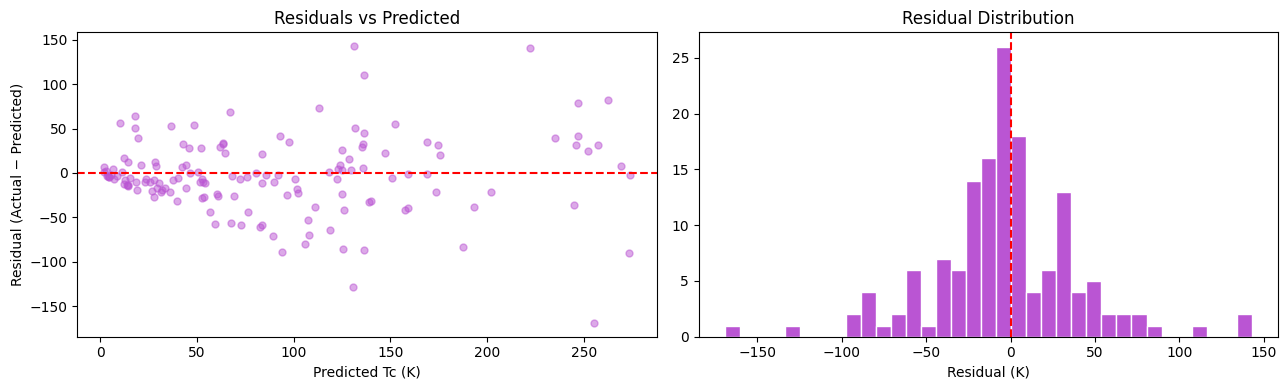

In [50]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_pred, residuals, alpha=0.5, color='mediumorchid', s=25)
axes[0].axhline(0, color='red', lw=1.5, linestyle='--')
axes[0].set_xlabel('Predicted Tc (K)')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=35, color='mediumorchid', edgecolor='white')
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Residual (K)')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

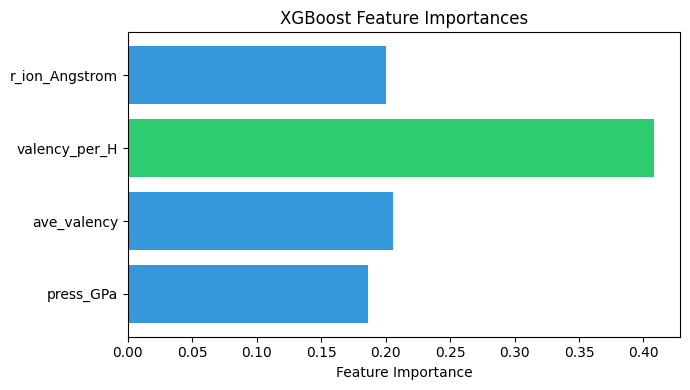

In [51]:
feature_names = ['press_GPa', 'ave_valency', 'valency_per_H', 'r_ion_Angstrom']
importances = best_model.feature_importances_  # from your best RF or XGB

plt.figure(figsize=(7, 4))
colors = ['#2ecc71' if x == max(importances) else '#3498db' for x in importances]
bars = plt.barh(feature_names, importances, color=colors)
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importances')
plt.tight_layout()
plt.show()

C:\Users\kotla\AppData\Local\Temp\ipykernel_13764\476916677.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Model', y='R2', ax=axes[0], palette='viridis')
C:\Users\kotla\AppData\Local\Temp\ipykernel_13764\476916677.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Model', y='RMSE', ax=axes[1], palette='magma')


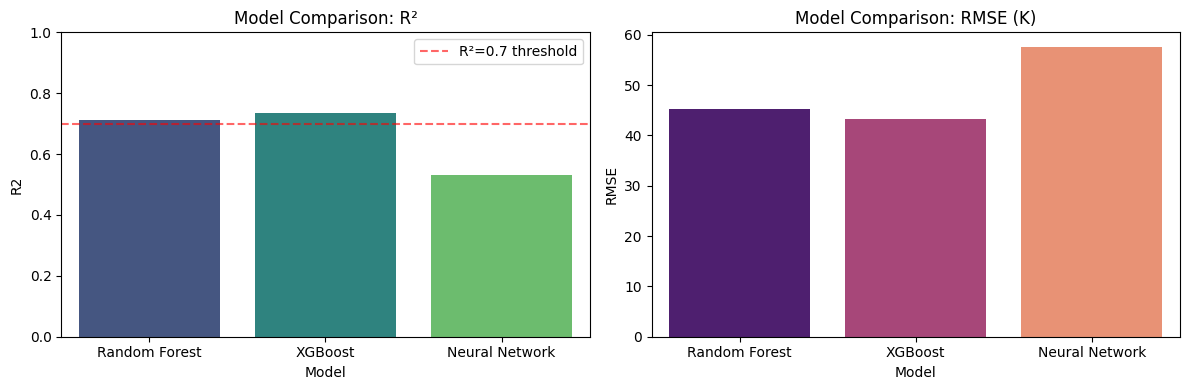

In [52]:
# Populate with your actual results from the notebook
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Neural Network'],
    'R2':    [0.711, 0.736, 0.532],
    'RMSE':  [45.24, 43.28, 57.60]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=comparison_df, x='Model', y='R2', ax=axes[0], palette='viridis')
axes[0].set_title('Model Comparison: R²')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.7, color='red', linestyle='--', alpha=0.6, label='R²=0.7 threshold')
axes[0].legend()

sns.barplot(data=comparison_df, x='Model', y='RMSE', ax=axes[1], palette='magma')
axes[1].set_title('Model Comparison: RMSE (K)')

plt.tight_layout()
plt.show()

In [59]:
# ── SVM Regressor ──────────────────────────────────────────────────────────────
from sklearn.svm import SVR


# --- Basic SVR (with scaling — mandatory for SVM) ---
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print("── Basic SVR ──")
print(f"MSE  : {mse_svm:.4f}")
print(f"RMSE : {rmse_svm:.4f}")
print(f"R²   : {r2_svm:.4f}")


── Basic SVR ──
MSE  : 5192.7605
RMSE : 72.0608
R²   : 0.2668


In [60]:
# --- Add SVM to the model comparison plot ---
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Neural Network', 'SVM'],
    'R2':    [0.711, 0.736, 0.532, r2_svm_best],
    'RMSE':  [45.24, 43.28, 57.60, rmse_svm_best]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=comparison_df, x='Model', y='R2', ax=axes[0], palette='viridis')
axes[0].set_title('Model Comparison: R²')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.7, color='red', linestyle='--', alpha=0.6, label='R²=0.7 threshold')
axes[0].legend()

sns.barplot(data=comparison_df, x='Model', y='RMSE', ax=axes[1], palette='magma')
axes[1].set_title('Model Comparison: RMSE (K)')

plt.tight_layout()
plt.show()

NameError: name 'r2_svm_best' is not defined

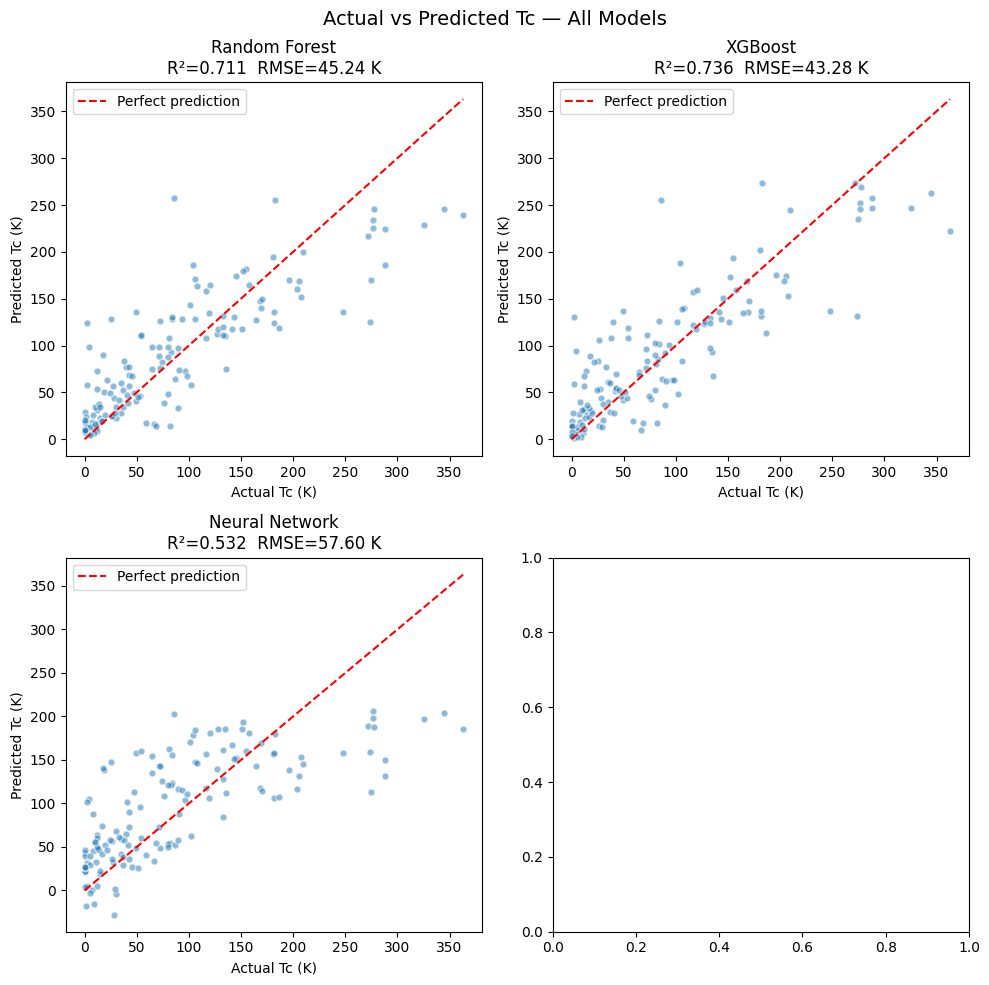

In [61]:
# ── Actual vs Predicted plots for all models ──────────────────────────────────
models = {
    "Random Forest": y_pred_rf,
    "XGBoost":       y_pred_xgb,        # from your XGBoost cell
    "Neural Network": y_pred_nn,
   
}

fig, axes = plt.subplots(2, 2,  figsize=(10, 10))
axes = axes.flatten()

for ax, (name, y_pred_model) in zip(axes, models.items()):
    r2   = r2_score(y_test, y_pred_model)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_model))
    max_val = max(y_test.max(), y_pred_model.max())

    ax.scatter(y_test, y_pred_model, alpha=0.5, s=25, edgecolors='white')
    ax.plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Tc (K)')
    ax.set_ylabel('Predicted Tc (K)')
    ax.set_title(f'{name}\nR²={r2:.3f}  RMSE={rmse:.2f} K')
    ax.legend()

plt.suptitle('Actual vs Predicted Tc — All Models', fontsize=14)
plt.tight_layout()
plt.show()

In [40]:
import joblib
joblib.dump(best_model, "tc_model.pkl")

['tc_model.pkl']

In [41]:
import json
json.dump(["press_GPa", "ave_valency", "valency_per_H", "r_ion_Angstrom"], 
          open("features.json", "w"))

In [39]:

import os

print(os.getcwd())  # this shows where the file is being saved
joblib.dump(xgb_model, "tc_model.pkl")
print("saved!", os.path.getsize("tc_model.pkl"), "bytes")

C:\Users\kotla
saved! 753 bytes
